<a href="https://colab.research.google.com/github/Lekhana-Y/ML/blob/main/dbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons




In [5]:
x,y=make_moons(n_samples=500,noise=0.05,random_state=42)

In [6]:
import pandas as pd

# Load the store_customer.csv file
df_customer = pd.read_csv('store_customers.csv')

# Display the first 5 rows and information about the DataFrame
display(df_customer.head())
display(df_customer.info())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


None

In [7]:
# Select relevant features for clustering and handle missing values
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X_customer = df_customer[features].dropna().values
print(f"Shape of data for clustering: {X_customer.shape}")

Shape of data for clustering: (990, 2)


In [8]:
scaler = StandardScaler()
X_scaled_customer = scaler.fit_transform(X_customer)


In [9]:
dbscan = DBSCAN(eps=0.25, min_samples=5)
labels = dbscan.fit_predict(X_scaled_customer)


In [10]:
n_clusters=len(set(labels))-(1 if -1 in labels else 0)
n_noise=list(labels).count(-1)

In [11]:
print(f"estimated no of clusters:{n_clusters}")
print(f"estimated no of noise points:{n_noise}")

estimated no of clusters:2
estimated no of noise points:10


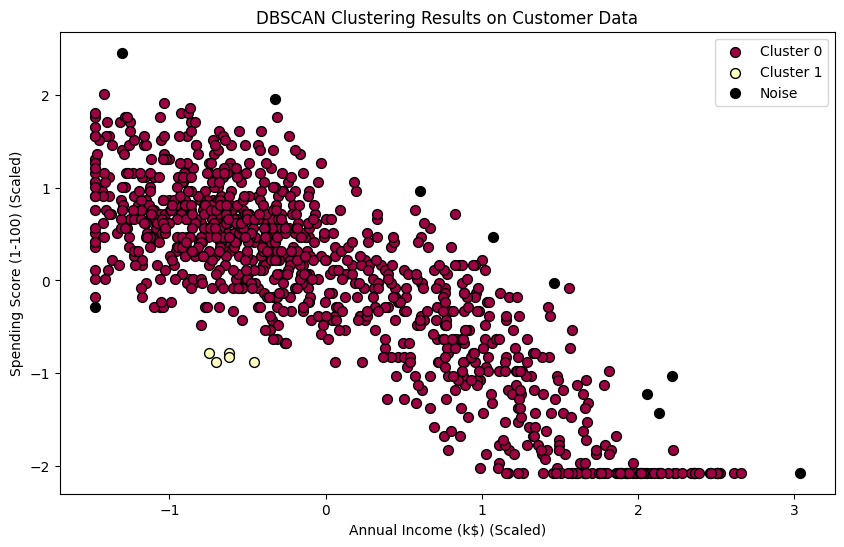

In [12]:

plt.figure(figsize=(10,6))
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]


for k, col in zip(unique_labels, colors):
    if k == -1:
      # Black used for noise.
      col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    plt.scatter(X_scaled_customer[class_member_mask, 0], X_scaled_customer[class_member_mask, 1],
                c=[col], edgecolors='k', s=50, label=f'Cluster {k}' if k != -1 else 'Noise')


plt.title("DBSCAN Clustering Results on Customer Data")
plt.xlabel(f"{features[0]} (Scaled)")
plt.ylabel(f"{features[1]} (Scaled)")
plt.legend()
plt.show()